# Penyelesaian Missing Value Konsentrasi Karbon Monoksida (CO) Menggunakan Metode Interpolasi Linear Bertahap

**Dataset Input**: `data/csv/pertemuan-3-csv/polutan_co_bangkalan_clean.csv`

## Tahap 1: Memuat Data Bebas Outlier dan Eksplorasi Profil Missing Values

=== PROFIL DATASET BEBAS OUTLIER (HARI 1 - 365) ===
Total Baris Data        : 365 hari
Rentang Tanggal         : 2025-08-24 s.d. 2026-08-23
Data Valid (Terisi)     : 233 hari
Missing Values (NaN)    : 132 hari


,tanggal,CO
0,2025-08-24,0.032369
1,2025-08-25,0.029644
2,2025-08-26,NaN
3,2025-08-27,0.028471
4,2025-08-28,0.024230


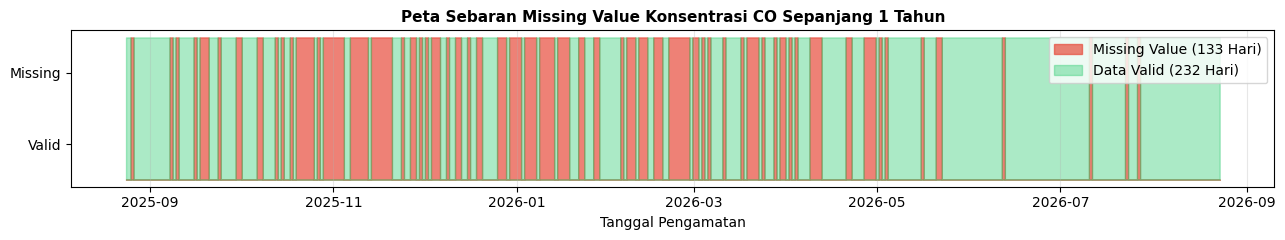

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

input_path = "../data/csv/pertemuan-3-csv/polutan_co_bangkalan_clean.csv"
if not os.path.exists(input_path):
    input_path = "data/csv/pertemuan-3-csv/polutan_co_bangkalan_clean.csv"

df = pd.read_csv(input_path)
df['tanggal'] = pd.to_datetime(df['tanggal'])

print("=== PROFIL DATASET BEBAS OUTLIER (HARI 1 - 365) ===")
print(f"Total Baris Data        : {len(df)} hari")
print(f"Rentang Tanggal         : {df['tanggal'].min().strftime('%Y-%m-%d')} s.d. {df['tanggal'].max().strftime('%Y-%m-%d')}")
print(f"Data Valid (Terisi)     : {df['CO'].notna().sum()} hari")
print(f"Missing Values (NaN)    : {df['CO'].isna().sum()} hari")
display(df.head())

plt.figure(figsize=(13, 2.5))
mask = df['CO'].isna().astype(int)
plt.fill_between(df['tanggal'], 0, mask, color='#e74c3c', alpha=0.7, step='mid', label='Missing Value (133 Hari)')
plt.fill_between(df['tanggal'], 0, 1 - mask, color='#2ecc71', alpha=0.4, step='mid', label='Data Valid (232 Hari)')
plt.title('Peta Sebaran Missing Value Konsentrasi CO Sepanjang 1 Tahun', fontsize=11, fontweight='bold')
plt.xlabel('Tanggal Pengamatan')
plt.yticks([0.25, 0.75], ['Valid', 'Missing'])
plt.grid(True, alpha=0.3, axis='x')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Tahap 2: Rumus Matematis & Komparasi Metode Imputasi

Formula Interpolasi Linear:
$$y(t) = y_0 + (t - t_0) \times \frac{y_1 - y_0}{t_1 - t_0}$$

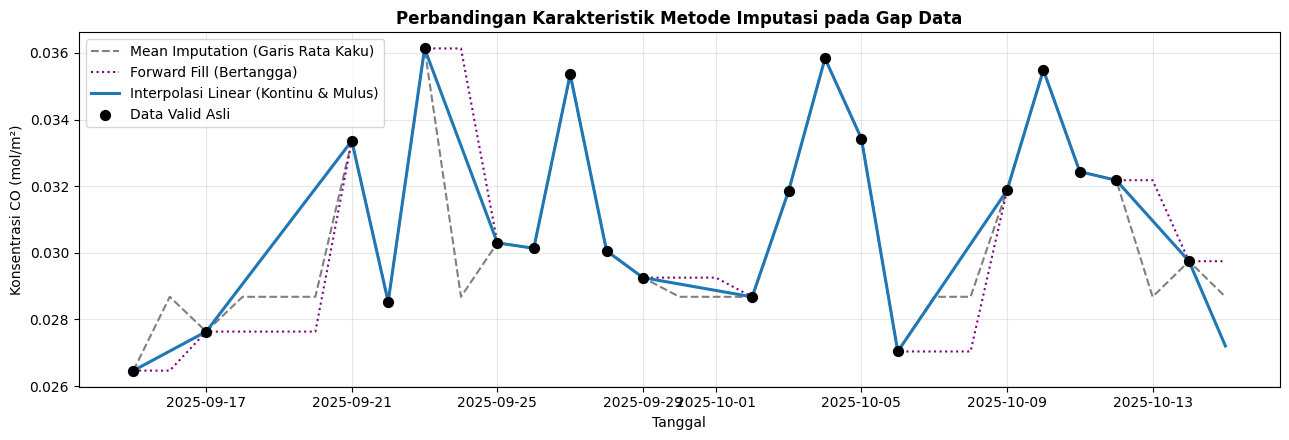

In [2]:
df_comp = df.copy()
df_comp['CO_mean'] = df_comp['CO'].fillna(df_comp['CO'].mean())
df_comp['CO_ffill'] = df_comp['CO'].ffill().bfill()
df_comp['CO_linear'] = df_comp['CO'].interpolate(method='linear')

zoom_mask = (df_comp['tanggal'] >= '2025-09-15') & (df_comp['tanggal'] <= '2025-10-15')
df_z = df_comp[zoom_mask]

plt.figure(figsize=(13, 4.5))
plt.plot(df_z['tanggal'], df_z['CO_mean'], label='Mean Imputation (Garis Rata Kaku)', linestyle='--', color='gray')
plt.plot(df_z['tanggal'], df_z['CO_ffill'], label='Forward Fill (Bertangga)', linestyle=':', color='purple', linewidth=1.5)
plt.plot(df_z['tanggal'], df_z['CO_linear'], label='Interpolasi Linear (Kontinu & Mulus)', color='#1f77b4', linewidth=2.2)
plt.scatter(df_z.dropna(subset=['CO'])['tanggal'], df_z.dropna(subset=['CO'])['CO'], color='black', s=50, zorder=5, label='Data Valid Asli')
plt.title('Perbandingan Karakteristik Metode Imputasi pada Gap Data', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi CO (mol/m²)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Tahap 3: Penerapan Interpolasi Linear Secara Bertahap

In [3]:
df_imputed = df.copy()
df_imputed['is_imputed'] = df_imputed['CO'].isna()
df_imputed['CO_imputed'] = df_imputed['CO'].interpolate(method='linear').bfill().ffill()

sisa_nan = df_imputed['CO_imputed'].isna().sum()
print("=== HASIL PENERAPAN INTERPOLASI LINEAR ===")
print(f"Total Baris Data            : {len(df_imputed)} hari")
print(f"Data Asli (Dipertahankan)   : {(~df_imputed['is_imputed']).sum()} hari")
print(f"Data Ditambal (Interpolasi) : {df_imputed['is_imputed'].sum()} hari")
print(f"Sisa Missing Value          : {sisa_nan} hari (100% LENGKAP)")
display(df_imputed[df_imputed['is_imputed'] == True][['tanggal', 'CO', 'CO_imputed', 'is_imputed']].head(10))

=== HASIL PENERAPAN INTERPOLASI LINEAR ===
Total Baris Data            : 365 hari
Data Asli (Dipertahankan)   : 233 hari
Data Ditambal (Interpolasi) : 132 hari
Sisa Missing Value          : 0 hari (100% LENGKAP)


,tanggal,CO,CO_imputed,is_imputed
2,2025-08-26,NaN,0.029057,True
15,2025-09-08,NaN,0.027982,True
17,2025-09-10,NaN,0.027978,True
23,2025-09-16,NaN,0.027050,True
25,2025-09-18,NaN,0.029066,True
26,2025-09-19,NaN,0.030497,True
27,2025-09-20,NaN,0.031928,True
31,2025-09-24,NaN,0.033215,True
37,2025-09-30,NaN,0.029062,True
38,2025-10-01,NaN,0.028870,True


## Tahap 4: Visualisasi Hasil Imputasi Linear

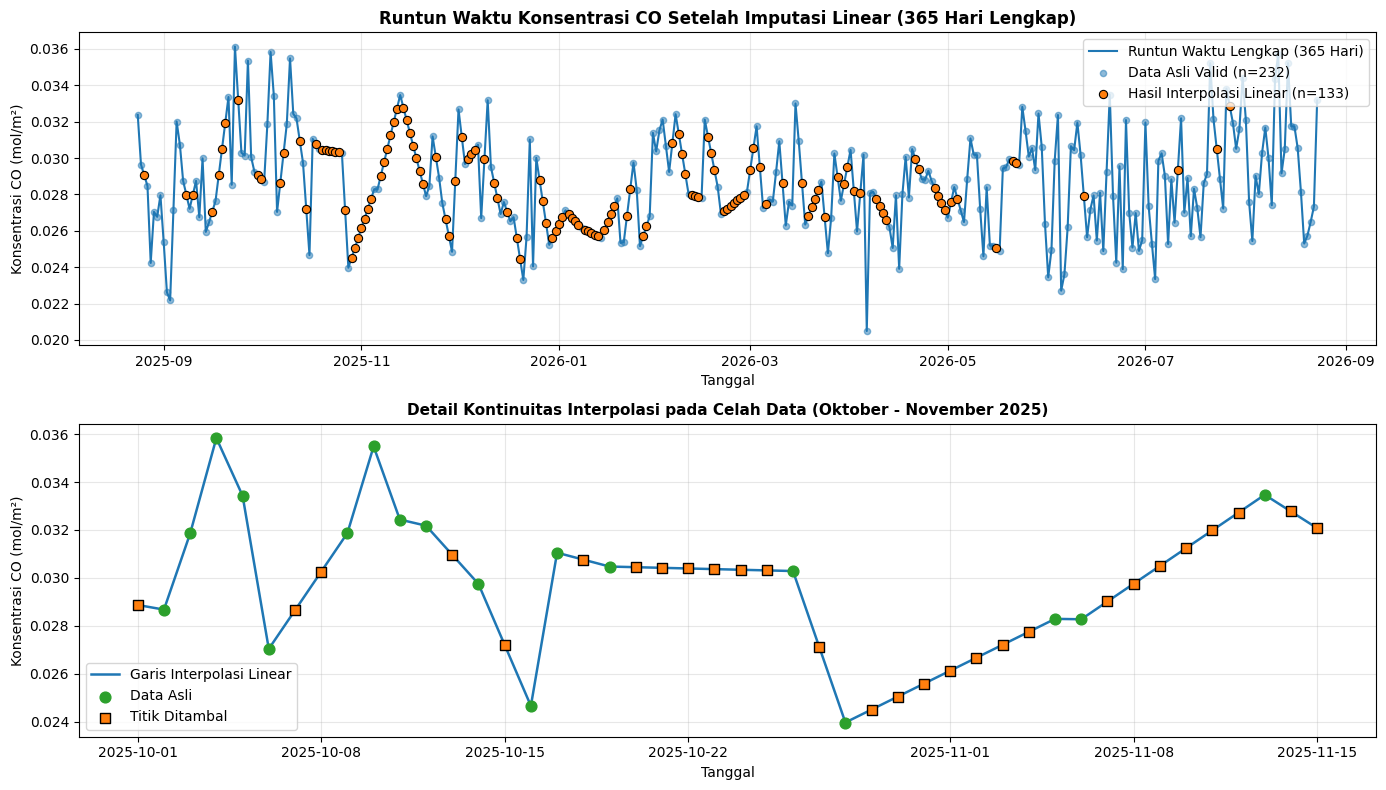

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 1. Full Time Series
axes[0].plot(df_imputed['tanggal'], df_imputed['CO_imputed'], color='#1f77b4', linewidth=1.5, label='Runtun Waktu Lengkap (365 Hari)')
axes[0].scatter(df_imputed[~df_imputed['is_imputed']]['tanggal'], df_imputed[~df_imputed['is_imputed']]['CO_imputed'], color='#1f77b4', s=20, alpha=0.5, label='Data Asli Valid (n=232)')
axes[0].scatter(df_imputed[df_imputed['is_imputed']]['tanggal'], df_imputed[df_imputed['is_imputed']]['CO_imputed'], color='#ff7f0e', marker='o', s=35, edgecolor='black', linewidth=0.8, zorder=5, label='Hasil Interpolasi Linear (n=133)')
axes[0].set_title('Runtun Waktu Konsentrasi CO Setelah Imputasi Linear (365 Hari Lengkap)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Konsentrasi CO (mol/m²)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# 2. Zoom-in
sub_mask = (df_imputed['tanggal'] >= '2025-10-01') & (df_imputed['tanggal'] <= '2025-11-15')
df_sub = df_imputed[sub_mask]
axes[1].plot(df_sub['tanggal'], df_sub['CO_imputed'], color='#1f77b4', linewidth=1.8, label='Garis Interpolasi Linear')
axes[1].scatter(df_sub[~df_sub['is_imputed']]['tanggal'], df_sub[~df_sub['is_imputed']]['CO_imputed'], color='#2ca02c', s=60, zorder=5, label='Data Asli')
axes[1].scatter(df_sub[df_sub['is_imputed']]['tanggal'], df_sub[df_sub['is_imputed']]['CO_imputed'], color='#ff7f0e', marker='s', s=60, edgecolor='black', zorder=5, label='Titik Ditambal')
axes[1].set_title('Detail Kontinuitas Interpolasi pada Celah Data (Oktober - November 2025)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Konsentrasi CO (mol/m²)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Tahap 5: Ekspor Data Bersih Sempurna

In [5]:
output_folder = "../data/csv/pertemuan-3-csv"
if not os.path.exists(output_folder) and os.path.exists("data/csv/pertemuan-3-csv"):
    output_folder = "data/csv/pertemuan-3-csv"
os.makedirs(output_folder, exist_ok=True)

df_final = pd.DataFrame({
    'tanggal': df_imputed['tanggal'].dt.strftime('%Y-%m-%d'),
    'CO': df_imputed['CO_imputed']
})

final_csv_path = os.path.join(output_folder, "polutan_co_bangkalan_final_clean.csv")
df_final.to_csv(final_csv_path, index=False)
print(f"✓ File data bersih sempurna berhasil disimpan di: {final_csv_path}")

print("\n=== VERIFIKASI AKHIR DATASET LENGKAP ===")
df_check = pd.read_csv(final_csv_path)
print(f"Total Baris Data        : {len(df_check)} baris (Tepat 365 hari)")
print(f"Jumlah Missing Value    : {df_check['CO'].isna().sum()} baris (0 NaN)")
print(f"Nilai Minimum CO        : {df_check['CO'].min():.8f}")
print(f"Rata-rata CO            : {df_check['CO'].mean():.8f}")
print(f"Nilai Maksimum CO       : {df_check['CO'].max():.8f}")
display(df_check.head())

✓ File data bersih sempurna berhasil disimpan di: ../data/csv/pertemuan-3-csv\polutan_co_bangkalan_final_clean.csv

=== VERIFIKASI AKHIR DATASET LENGKAP ===
Total Baris Data        : 365 baris (Tepat 365 hari)
Jumlah Missing Value    : 0 baris (0 NaN)
Nilai Minimum CO        : 0.02048735
Rata-rata CO            : 0.02858408
Nilai Maksimum CO       : 0.03613363


,tanggal,CO
0,2025-08-24,0.032369
1,2025-08-25,0.029644
2,2025-08-26,0.029057
3,2025-08-27,0.028471
4,2025-08-28,0.024230
